#Monai is an effective framework for preprocessing NIfTI images for a pytorch pipeline
!pip install monai
!pip install tqdm
!pip install scikit-learn #for dividing training and val sets

In [2]:
import os
from glob import glob
from pathlib import Path
import torch
import torchvision
import monai
from sklearn.model_selection import train_test_split
from monai.transforms import ( #d stands for dictionary
    AsDiscrete,
    AsDiscreted,
    Compose,
    DivisiblePadD,
    LoadImaged,
    ToTensord,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    Resized,
    MapLabelValueD,
    CastToTyped,
    ConcatItemsd,
    Invertd,
    SaveImaged
)
from monai.data import CacheDataset, Dataset, DataLoader, decollate_batch
from monai.inferers import sliding_window_inference
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.utils import first
from monai.handlers.utils import from_engine
import matplotlib.pyplot as plt
import nibabel as nib 
print(torch.__version__)
print(torchvision.__version__)
print(monai.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.6.0+cu124
0.21.0+cu124
1.5.0
12.4
NVIDIA GeForce RTX 5070 Ti


/home/leeha/miniconda3/envs/medcv-gpu-nightly/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [6]:
data_dir = 'data' #path from our current directory

In [7]:
#load file paths and store as a dictionary for each subject
data_root = Path("data") / "brats20_output" / "Training" #create path object that points to our data directory

subjects = [] #create empy list of dictionaries
for subject_dir in sorted(data_root.glob("BraTS20_Training_*")): #sorted makes sure our folders are accessed in order, glob allows us to use *, for loop iterates over all folders
    subject = {
        "flair": subject_dir / f"{subject_dir.name}_flair.nii", #each key corresponds to a file path
        "t1": subject_dir / f"{subject_dir.name}_t1.nii",
        "t1ce": subject_dir / f"{subject_dir.name}_t1ce.nii",
        "t2": subject_dir / f"{subject_dir.name}_t2.nii",
        "seg": subject_dir / f"{subject_dir.name}_seg.nii"
    }

    # You can optionally check they all exist
    if all(p.exists() for p in subject.values()):
        subjects.append(subject)
    else:
        print(f"Missing files for {subject_dir.name}")

print(f"Loaded {len(subjects)} complete subject dictionaries.")

#load file paths and store as a dictionary for each subject
data_root = Path("data") / "brats20_output" / "Validation" #create path object that points to our data directory

val_subjects = [] #create empy list of dictionaries
for subject_dir in sorted(data_root.glob("BraTS20_Training_*")): #sorted makes sure our folders are accessed in order, glob allows us to use *, for loop iterates over all folders
    val_subject = {
        "flair": subject_dir / f"{subject_dir.name}_flair.nii", #each key corresponds to a file path
        "t1": subject_dir / f"{subject_dir.name}_t1.nii",
        "t1ce": subject_dir / f"{subject_dir.name}_t1ce.nii",
        "t2": subject_dir / f"{subject_dir.name}_t2.nii",
        "seg": subject_dir / f"{subject_dir.name}_seg.nii"
    }

    # You can optionally check they all exist
    if all(p.exists() for p in val_subject.values()):
        val_subjects.append(val_subject)
    else:
        print(f"Missing files for {subject_dir.name}")

print(f"Loaded {len(val_subjects)} complete subject dictionaries.")
#print(subjects)
# '''
# Brats2020 does not provide labels for validation data... best we can do is split our  model into training and validation set
# '''
# train_subjects, val_subjects = train_test_split(subjects, test_size=0.2, random_state=42)
# print(len(train_subjects))
# print(len(val_subjects))


Loaded 295 complete subject dictionaries.
Loaded 74 complete subject dictionaries.


subject 0


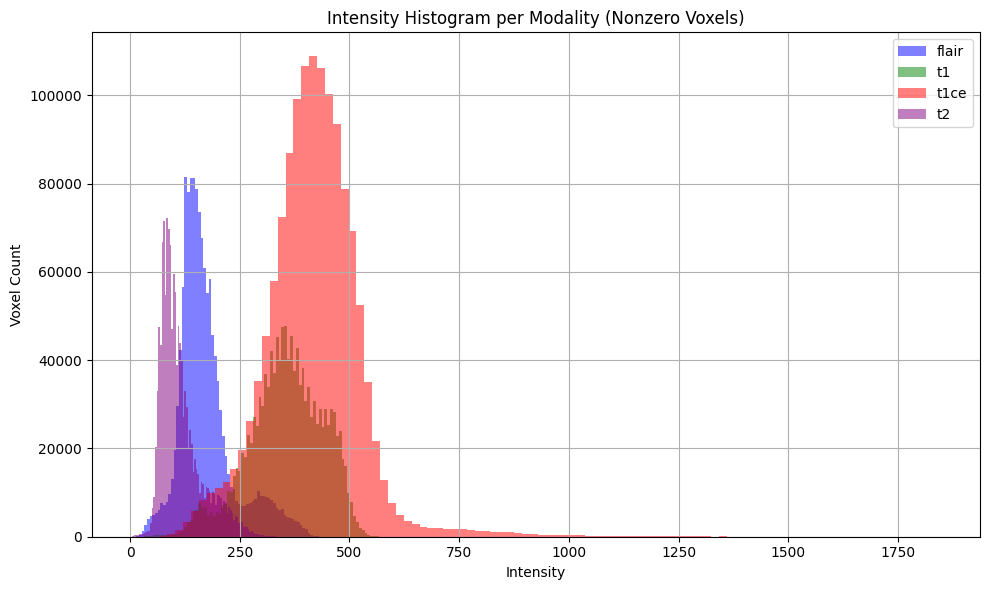

subject 1


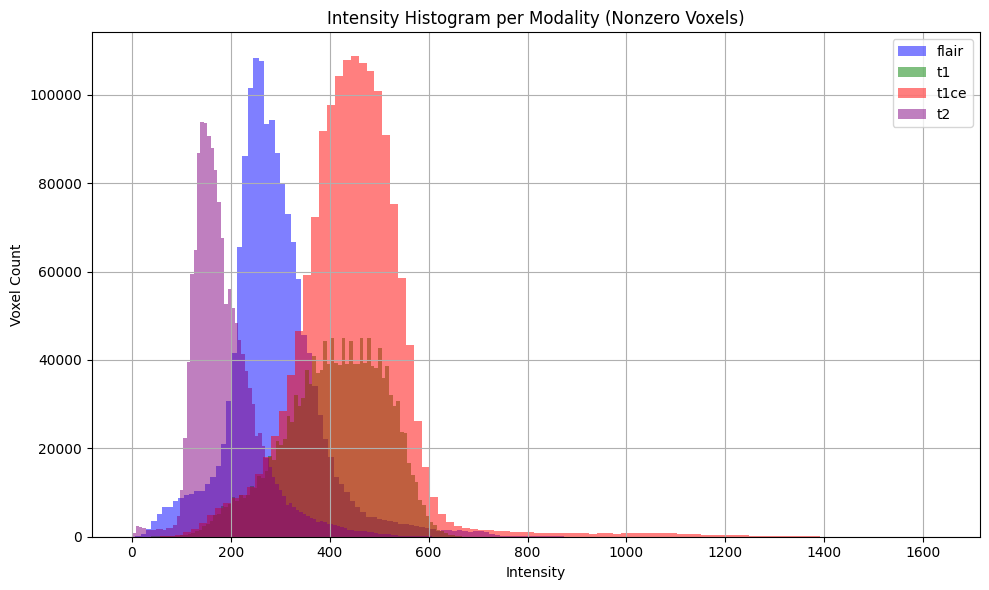

subject 2


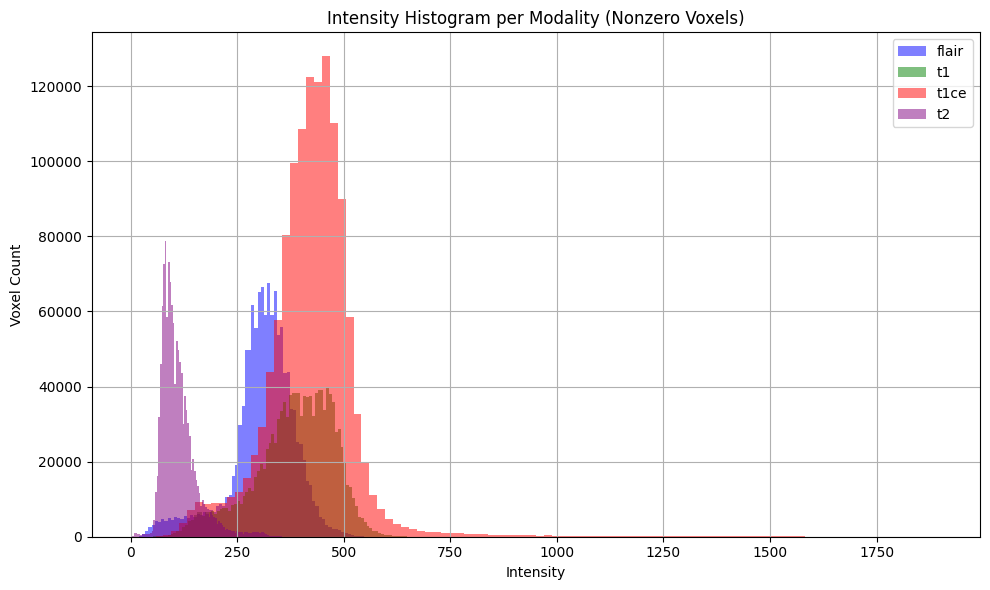

subject 3


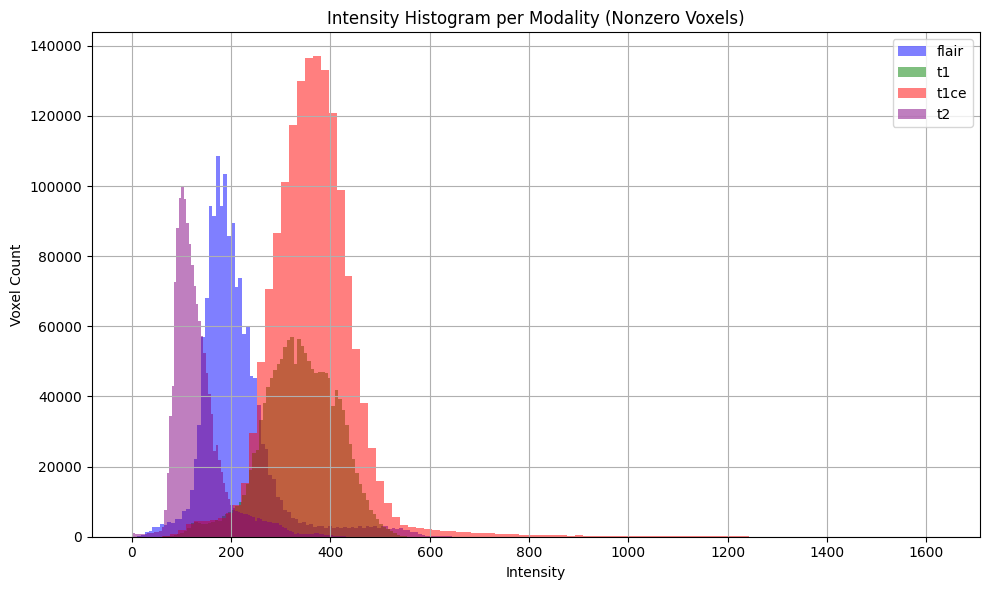

subject 4


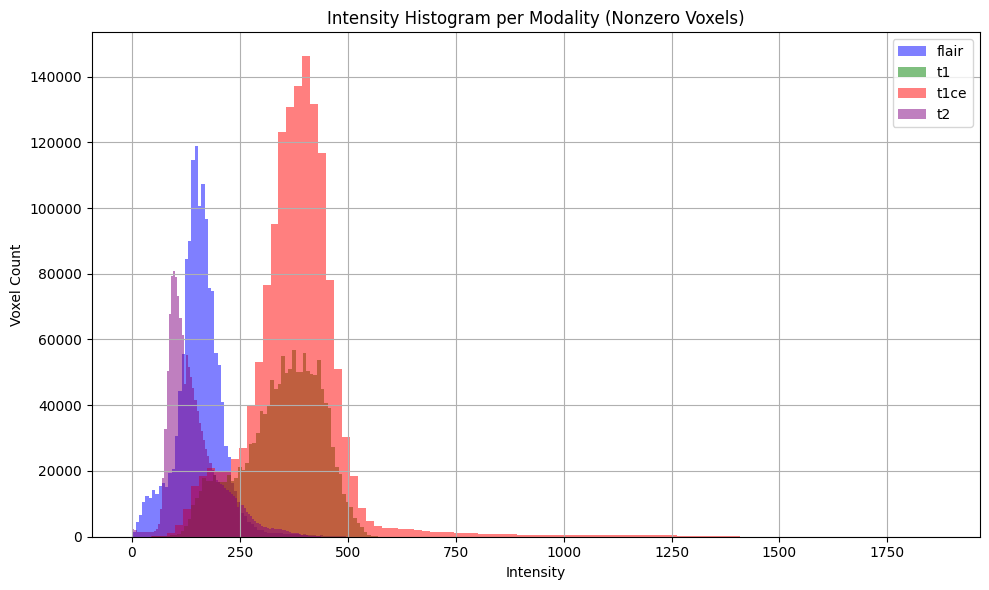

subject 5


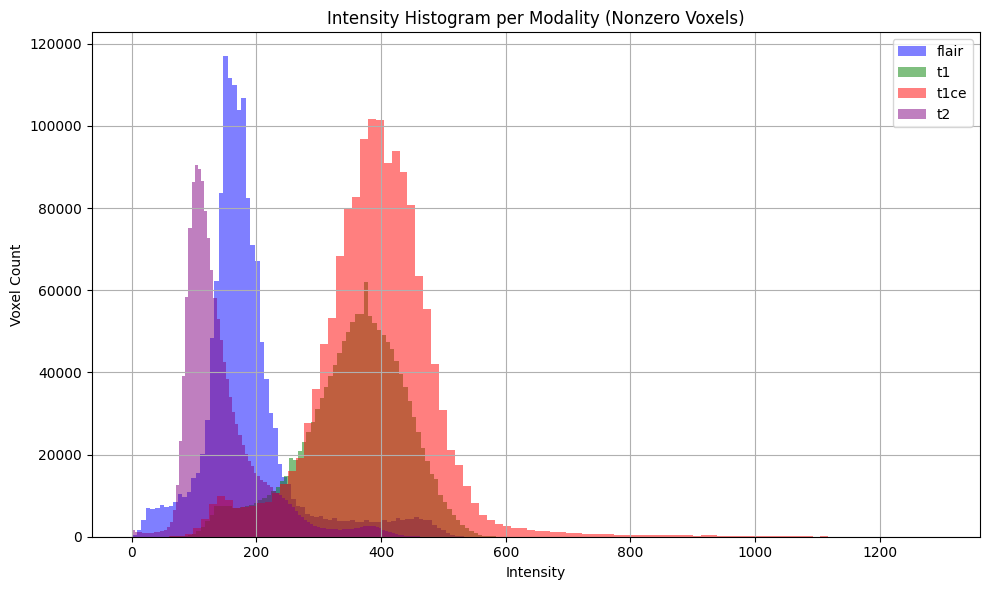

subject 6


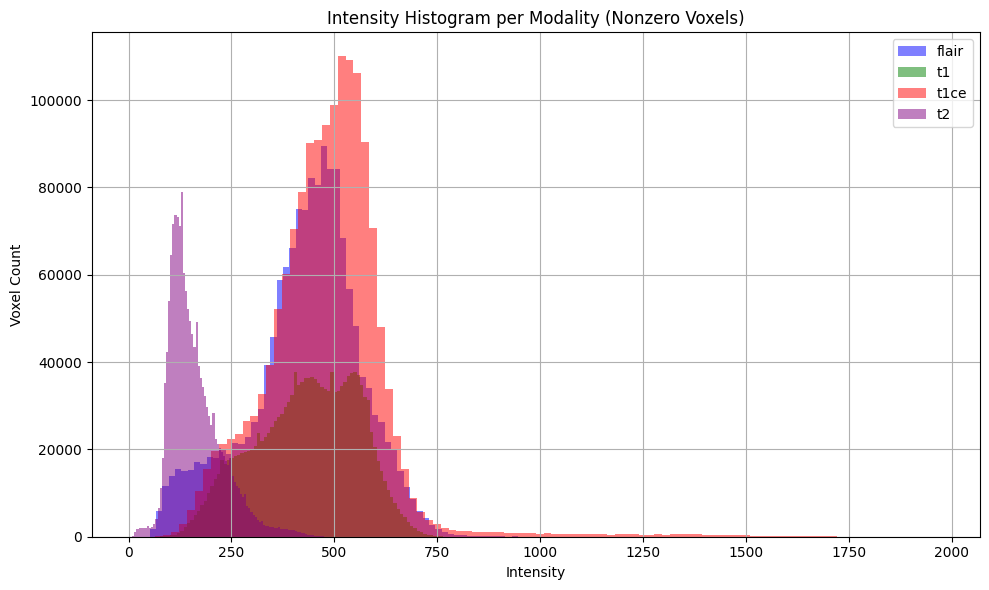

subject 7


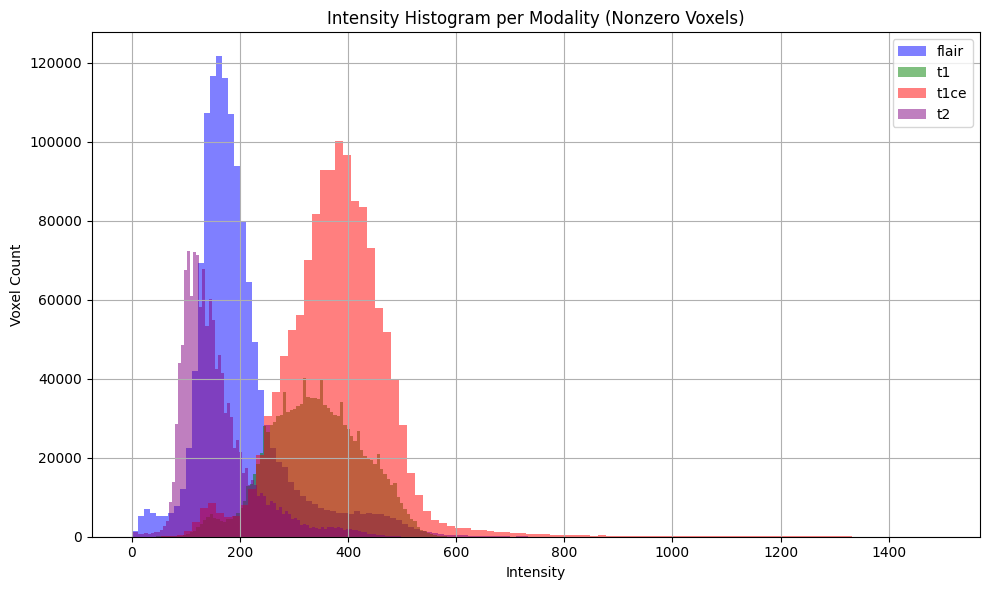

subject 8


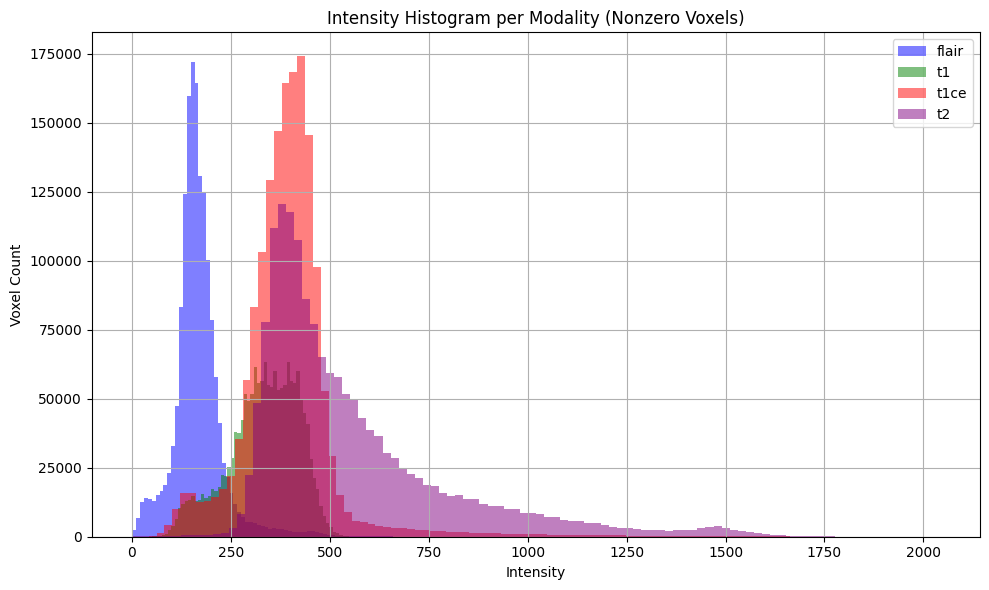

subject 9


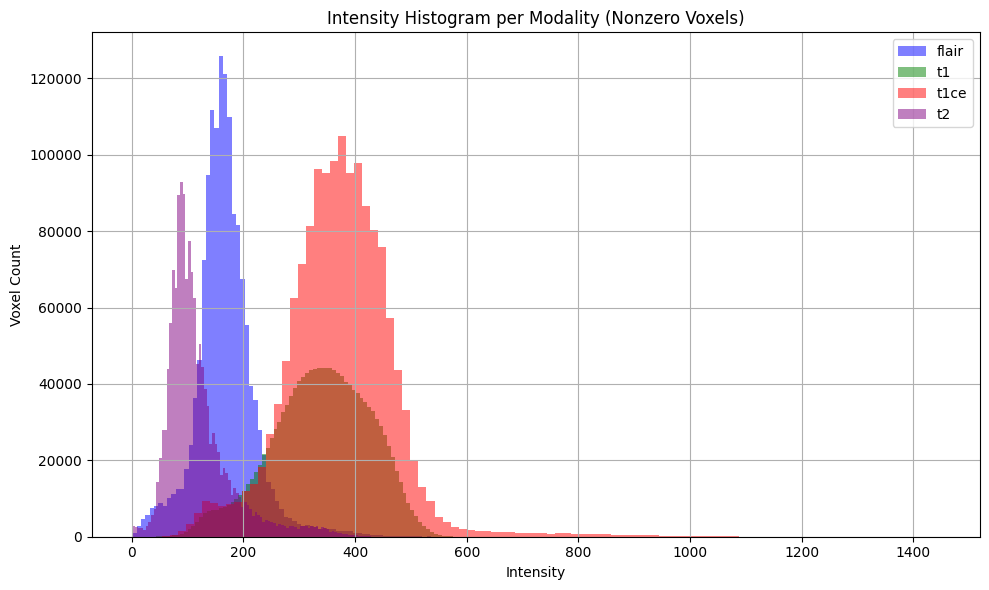

In [8]:
'''
Before we make our tensors it is important that we consider what our image contrast should be. 
We are using 4 different scan types, and it would be nice if we could find a single tight contrast range that will work for all of them without washing
out details
We can decide on the contrast range to use by generating histograms for each image type
supplement this with online ITK-Snap tool
'''
import matplotlib.pyplot as plt
import nibabel as nib

def plot_intensity_histograms(subject_dict):
    plt.figure(figsize=(10, 6))

    for key, color in zip(["flair", "t1", "t1ce", "t2"], ["blue", "green", "red", "purple"]):
        img = nib.load(str(subject_dict[key])).get_fdata()
        flat = img.flatten()
        flat = flat[flat > 0]  # Remove background (optional)
        plt.hist(flat, bins=100, alpha=0.5, label=key, color=color)

    plt.title("Intensity Histogram per Modality (Nonzero Voxels)")
    plt.xlabel("Intensity")
    plt.ylabel("Voxel Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
for i in range(10):
    print(f"subject {i}")
    plot_intensity_histograms(subjects[i]) #a range of 0 to 600 looks great
#plot_intensity_histograms(subjects[0])

In [9]:
#load images
#do transformations
#convert to torch tensors
original_transforms = Compose(
    [
        LoadImaged(keys=['flair', 't1', 't1ce', 't2', 'seg']), #d stands for dictionary, we load every key for 1 row (1 patient), data loader will carry this out for every row
        EnsureChannelFirstd(keys=['flair', 't1', 't1ce', 't2', 'seg']),
        #
        ToTensord(keys=['flair', 't1', 't1ce', 't2', 'seg']) #d stands for dictionary, do this AFTER transforms :)
    ]
)

#consider using itk-snap to find good contrast values
#removed clip = True under scaleintensity
'''
Take note of EnsureChannelFirst: it converts our NIfTI images from HxWxD format to CxHxWxD format
C is number of channels, in our case we want 4, each pixel will contain values from all 4 training images
D is depth, number of slices
'''
image = nib.load(subjects[0]["flair"])
print(image.shape)

train_transforms = Compose(
    [
        LoadImaged(keys=['flair', 't1', 't1ce', 't2', 'seg']), #d stands for dictionary, we load every key for 1 row (1 patient), data loader will carry this out for every row
        EnsureChannelFirstd(keys=['flair', 't1', 't1ce', 't2', 'seg']),
        Spacingd(keys=['flair', 't1', 't1ce', 't2', 'seg'], pixdim=(1.5, 1.5, 2)), #specify height width depth of voxels, this value can vary if we dont control it
        ScaleIntensityRanged(keys=['flair', 't1', 't1ce', 't2'], a_min = 0, a_max = 600, b_min = 0.0, b_max = 1.0), #don't apply to label
        CropForegroundd(keys=['flair', 't1', 't1ce', 't2', 'seg'], source_key='t1ce'),
        #Resized(keys=['flair', 't1', 't1ce', 't2', 'seg'], spatial_size=[128, 128, 128]),
        DivisiblePadD(keys=['flair', 't1', 't1ce','t2','seg'], k =16),
        MapLabelValueD(keys="seg", orig_labels =[0, 1, 2, 4], target_labels=[0,1,2,3]), #remap seg labels because MONAI expects contiguous labels
        CastToTyped(keys=["seg"], dtype=torch.int16), #labels need to be integers when fed to models, LoadImaged converts them to floats by default so we convert them back here
        ToTensord(keys=['flair', 't1', 't1ce', 't2']), #d stands for dictionary, do this AFTER transforms :)
        ConcatItemsd(keys=["flair", "t1", "t1ce","t2"], name = "image") #we stack our keys into a single tensor
    ]
)

'''
Normally we separate training and validation transformation because training transforms may include random augmentations. In our case we did not
include any, but we may later
'''

val_transforms = Compose(
    [
        LoadImaged(keys=['flair', 't1', 't1ce', 't2', 'seg']), #d stands for dictionary, we load every key for 1 row (1 patient), data loader will carry this out for every row
        EnsureChannelFirstd(keys=['flair', 't1', 't1ce', 't2', 'seg']),
        Spacingd(keys=['flair', 't1', 't1ce', 't2', 'seg'], pixdim=(1.5, 1.5, 2)), #specify height width depth of voxels, this value can vary if we dont control it
        ScaleIntensityRanged(keys=['flair', 't1', 't1ce', 't2'], a_min = 0, a_max = 600, b_min = 0.0, b_max = 1.0), #don't apply to label
        CropForegroundd(keys=['flair', 't1', 't1ce', 't2', 'seg'], source_key='t1ce'),
        #Resized(keys=['flair', 't1', 't1ce', 't2', 'seg'], spatial_size=[128, 128, 128]),
        DivisiblePadD(keys=['flair', 't1', 't1ce','t2','seg'], k =16),
        MapLabelValueD(keys="seg", orig_labels =[0, 1, 2, 4], target_labels=[0,1,2,3]), #remap seg labels because MONAI expects contiguous labels
        CastToTyped(keys=["seg"], dtype=torch.int16), #labels need to be integers when fed to models, LoadImaged converts them to floats by default so we convert them back here
        ToTensord(keys=['flair', 't1', 't1ce', 't2']), #d stands for dictionary, do this AFTER transforms :)
        ConcatItemsd(keys=["flair", "t1", "t1ce","t2"], name = "image") #we stack our keys into a single tensor
    ]
)


(240, 240, 155)


/home/leeha/miniconda3/envs/medcv-gpu/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [10]:
#We are about to use monai to transform our images, lets examine how the metadata for these images looks before and after
def inspect_sample(dataset, index=0):
    sample = dataset[index]

    image = sample["image"]
    label = sample["seg"]

    print(f"Image type: {type(image)}")
    print(f"Image shape: {image.shape}")
    print(f"Image dtype: {image.dtype}")

    print(f"\nLabel type: {type(label)}")
    print(f"Label shape: {label.shape}")
    print(f"Label dtype: {label.dtype}")

In [11]:
'''
We now use monai wrappers for pytorch.utils.datasets
'''
orig_ds = Dataset(data=subjects, transform=original_transforms) #this will automatically handle transforms tasks for all patients, no loop needed
orig_loader = DataLoader(orig_ds, batch_size=1)

train_ds = Dataset(data=subjects, transform=train_transforms) #this will automatically handle transforms tasks for all patients, no loop needed
train_loader = DataLoader(train_ds, batch_size=1)
inspect_sample(train_ds, index=0) 
#inspection tells us a few things
#Monai has converted our data to a pytorch compatible tensor
#It has converted our training data into 4 channel tensors (one for each image type)
#Our training data it correctly being treated as floats and our training labels as integers

Image type: <class 'monai.data.meta_tensor.MetaTensor'>
Image shape: torch.Size([4, 96, 128, 80])
Image dtype: torch.float32

Label type: <class 'monai.data.meta_tensor.MetaTensor'>
Label shape: torch.Size([1, 96, 128, 80])
Label dtype: torch.int16


In [12]:
test_patient = first(train_loader) #lets load 1 slice from 1 patient to verify our transformations
orig_patient = first(orig_loader)
# print(test_patient)#this contains image and label (all 5 columns)
# print(test_patient['seg']) #print just the labels

In [13]:
print(torch.min(test_patient['t1']))
print(torch.max(test_patient['t1']))

metatensor(0.)
metatensor(1.0233)


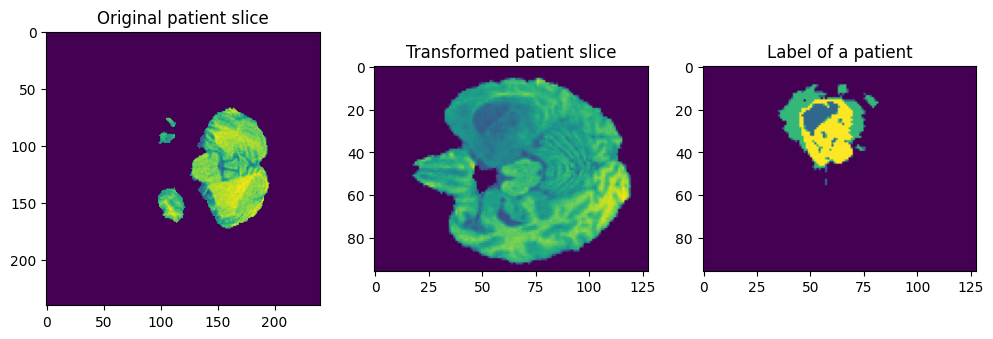

In [14]:
plt.figure('test', (12,6))#create matplots

plt.subplot(1, 3, 1) #1 line, 2 columns #I actually think the dimensions were standarddized before I got these images
plt.title('Original patient slice')
plt.imshow(orig_patient['t1'][0, 0, :, :, 30]) #index of batch and chanel, width, height, #ofslices  :== all

plt.subplot(1, 3, 2) #1 line, 2 columns
plt.title('Transformed patient slice')
plt.imshow(test_patient['t1'][0, 0, :, :, 30]) #index of batch and chanel, width, height, #ofslices  :== all

plt.subplot(1,3,3) #1 row 2 columns part 2
plt.title('Label of a patient')
plt.imshow(test_patient['seg'][0, 0, :, :,30])
plt.show()

In [15]:
'''
Now we have taken a look at our image data and preprocessed it, lets begin our actual training loop
CacheDataset is faster than dataset for training
'''
train_ds = CacheDataset(data=subjects, transform=train_transforms, cache_rate = 1.0, num_workers= 4) #this will automatically handle transforms tasks for all patients, no loop needed
train_loader = DataLoader(train_ds, batch_size=1, num_workers=4) #only 1 batch because we are not applying a random augmentation

val_ds = CacheDataset(data=val_subjects, transform=val_transforms, cache_rate = 1.0, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=4)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████| 74/74 [00:29<00:00,  2.47it/s]


In [16]:
#set up model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3, #3D images
    in_channels=4, #t1, t1ce, t2, flair
    out_channels=4, #4 seg classes background, edema, non-enhancing tumor, enhancing tumor
    channels=(16, 32, 64, 128, 256),
    strides=(2,2,2,2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True) #cross entropy loss
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=True)

In [17]:
max_epochs = 1 #600 later, 1 for now because running on CPU
val_interval = 1 #2 later
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=4)]) #4 for 4 classes
post_label = Compose([AsDiscrete(to_onehot=4)])

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device), #we set up the image tag with concat earlier
            batch_data["seg"].to(device),
        )
        print(inputs.shape)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["seg"].to(device),
                )
                roi_size = (160, 160, 160)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric, not_nans = dice_metric.aggregate() #bc not_nans = True, metric is 1D tensor
            mean_dice = (metric * not_nans).sum() / not_nans.sum() #we extract the not_nans from the tensor 
            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if mean_dice > best_metric:
                best_metric = mean_dice
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(data_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {mean_dice.item():.4f}" #we use.item() to extract the scalar value from our tensor
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
           )

----------
epoch 1/1
torch.Size([1, 4, 96, 128, 80])


RuntimeError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [17]:
print(f"training completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")

training completed, best_metric: 0.0058 at epoch: 1


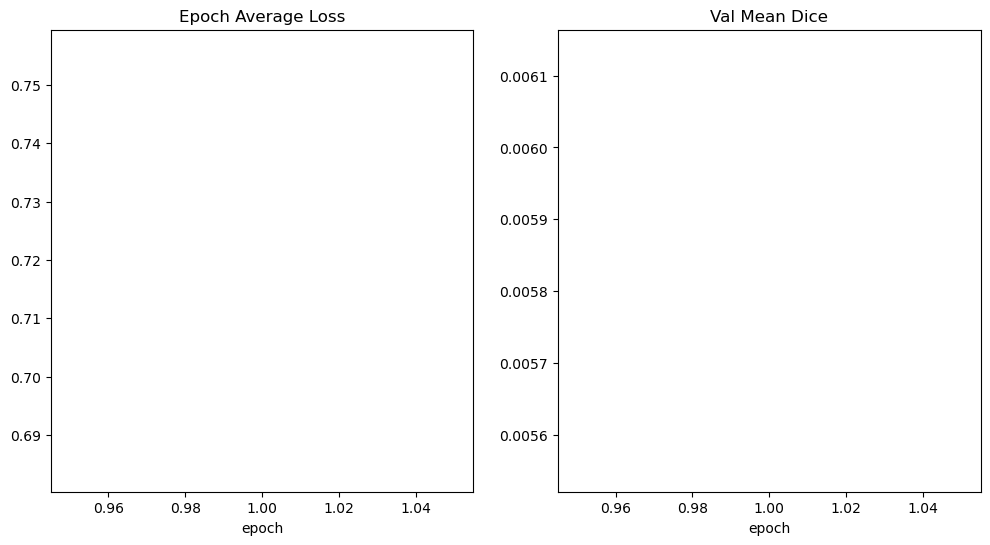

In [18]:
#Plot loss and metric
plt.figure("train", (12,6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x,y)
plt.show()

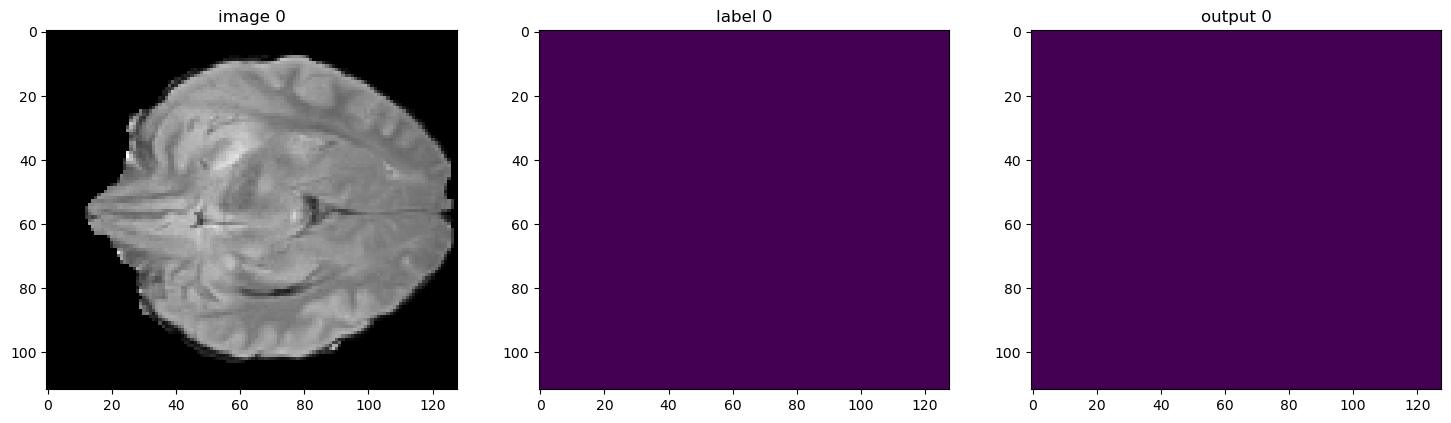

In [22]:
model.load_state_dict(torch.load(os.path.join(data_dir, "best_metric_model.pth"), weights_only=True))
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model)
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, :, :, 30], cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["seg"][0, 0, :, :, 30])
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        plt.imshow(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, 30])
        plt.show()
        if i == 0:
            break

In [27]:
val_org_transforms = Compose( #note this currently the same as val_transforms
    [
        LoadImaged(keys=['flair', 't1', 't1ce', 't2', 'seg']), #d stands for dictionary, we load every key for 1 row (1 patient), data loader will carry this out for every row
        EnsureChannelFirstd(keys=['flair', 't1', 't1ce', 't2', 'seg']),
        Spacingd(keys=['flair', 't1', 't1ce', 't2', 'seg'], pixdim=(1.5, 1.5, 2)), #specify height width depth of voxels, this value can vary if we dont control it
        ScaleIntensityRanged(keys=['flair', 't1', 't1ce', 't2'], a_min = 0, a_max = 600, b_min = 0.0, b_max = 1.0), #don't apply to label
        CropForegroundd(keys=['flair', 't1', 't1ce', 't2', 'seg'], source_key='t1ce'),
        #Resized(keys=['flair', 't1', 't1ce', 't2', 'seg'], spatial_size=[128, 128, 128]),
        DivisiblePadD(keys=['flair', 't1', 't1ce','t2','seg'], k =16),
        MapLabelValueD(keys="seg", orig_labels =[0, 1, 2, 4], target_labels=[0,1,2,3]), #remap seg labels because MONAI expects contiguous labels
        CastToTyped(keys=["seg"], dtype=torch.int16), #labels need to be integers when fed to models, LoadImaged converts them to floats by default so we convert them back here
        ToTensord(keys=['flair', 't1', 't1ce', 't2']), #d stands for dictionary, do this AFTER transforms :)
        ConcatItemsd(keys=["flair", "t1", "t1ce","t2"], name = "image") #we stack our keys into a single tensor
    ]
)

val_org_ds = Dataset(data=val_subjects, transform=val_org_transforms)
val_org_loader = DataLoader(val_org_ds, batch_size=1, num_workers=4)

post_transforms = Compose(
    [
        Invertd(
            keys="pred",
            transform=val_org_transforms,
            orig_keys="image",
            meta_keys="pred_meta_dict",
            orig_meta_keys="image_meta_dict",
            meta_key_postfix="meta_dict",
            nearest_interp=False,
            to_tensor=True,
            device="cpu",
        ),
        AsDiscreted(keys="pred", argmax=True, to_onehot=4),
        AsDiscreted(keys="seg", to_onehot=4),
    ]
)

In [36]:
model.load_state_dict(torch.load(os.path.join(data_dir, "best_metric_model.pth"), weights_only = True))
model.eval()

with torch.no_grad():
    for val_data in val_org_loader:
        val_inputs = val_data["image"].to(device)
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        val_data["pred"] = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
        val_data = [post_transforms(i) for i in decollate_batch(val_data)]
        val_outputs, val_labels = from_engine(["pred", "seg"])(val_data)
        # compute metric for current iteration
        dice_metric(y_pred=val_outputs, y=val_labels)

    # Get per-class Dice and valid-mask
    metric, not_nans = dice_metric.aggregate()

    # Manually compute mean Dice across valid classes
    mean_dice = (metric * not_nans).sum() / not_nans.sum()

    # Reset the metric tracker for next round
    dice_metric.reset()

    # Use mean_dice.item() for logging or comparison
    print(f"Mean Dice this epoch: {mean_dice.item():.4f}")


Mean Dice this epoch: 0.0058


In [41]:
from pathlib import Path
import glob

# Path to folder with validation NIfTI files
test_dir = Path("data") / "BraTS2020_ValidationData" / "MICCAI_BraTS2020_ValidationData"

# Find all patient folders and stack the 4 modalities into dicts
test_images = sorted(test_dir.glob("**/*.nii.gz"))

# Filter and group into 4-modality sets
from collections import defaultdict

# Group images by patient
patients = defaultdict(dict)
for path in test_images:
    patient_id = path.parent.name
    modality = path.name.split(".")[0]  # "flair", "t1", etc.
    patients[patient_id][modality] = str(path)

# Create test_data list
test_data = [
    {
        "flair": patient["flair"],
        "t1": patient["t1"],
        "t1ce": patient["t1ce"],
        "t2": patient["t2"]
    }
    for patient in patients.values()
    if all(modality in patient for modality in ["flair", "t1", "t1ce", "t2"])
]

test_org_transforms = Compose(
    [
        LoadImaged(keys=['flair', 't1', 't1ce', 't2', 'seg']), #d stands for dictionary, we load every key for 1 row (1 patient), data loader will carry this out for every row
        EnsureChannelFirstd(keys=['flair', 't1', 't1ce', 't2', 'seg']),
        Spacingd(keys=['flair', 't1', 't1ce', 't2', 'seg'], pixdim=(1.5, 1.5, 2)), #specify height width depth of voxels, this value can vary if we dont control it
        ScaleIntensityRanged(keys=['flair', 't1', 't1ce', 't2'], a_min = 0, a_max = 600, b_min = 0.0, b_max = 1.0), #don't apply to label
        CropForegroundd(keys=['flair', 't1', 't1ce', 't2', 'seg'], source_key='t1ce'),
        #Resized(keys=['flair', 't1', 't1ce', 't2', 'seg'], spatial_size=[128, 128, 128]),
        DivisiblePadD(keys=['flair', 't1', 't1ce','t2','seg'], k =16),
        MapLabelValueD(keys="seg", orig_labels =[0, 1, 2, 4], target_labels=[0,1,2,3]), #remap seg labels because MONAI expects contiguous labels
        CastToTyped(keys=["seg"], dtype=torch.int16), #labels need to be integers when fed to models, LoadImaged converts them to floats by default so we convert them back here
        ToTensord(keys=['flair', 't1', 't1ce', 't2']), #d stands for dictionary, do this AFTER transforms :)
        ConcatItemsd(keys=["flair", "t1", "t1ce","t2"], name = "image") #we stack our keys into a single tensor
    ]
)

test_org_ds = Dataset(data=test_data, transform=test_org_transforms)
test_org_loader = DataLoader(test_org_ds, batch_size=1, num_workers=4)

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=test_org_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=True,  # Segmentation → nearest is better
        to_tensor=True,
        device=device,
    ),
    AsDiscreted(keys="pred", argmax=True, to_onehot=4),
    SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
])


In [37]:
#visualize predicted results
from monai.transforms import LoadImage
loader = LoadImage()

In [43]:
model.load_state_dict(torch.load(os.path.join(data_dir, "best_metric_model.pth"), weights_only=True))
model.eval()

with torch.no_grad():
    for test_data in test_org_loader:
        test_inputs = test_data["image"].to(device)
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        test_data["pred"] = sliding_window_inference(test_inputs, roi_size, sw_batch_size, model)

        test_data = [post_transforms(i) for i in decollate_batch(test_data)]

#         # uncomment the following lines to visualize the predicted results
#         test_output = from_engine(["pred"])(test_data)

#         original_image = loader(test_output[0].meta["filename_or_obj"])

#         plt.figure("check", (18, 6))
#         plt.subplot(1, 2, 1)
#         plt.imshow(original_image[:, :, 20], cmap="gray")
#         plt.subplot(1, 2, 2)
#         plt.imshow(test_output[0].detach().cpu()[1, :, :, 20])
#         plt.show()